
# Day 2 practical: Regression and predictive modelling in Python

In this session we will use Python to explore supervised learning, linear and polynomial regression, loss functions, gradient descent, decision-tree regression, resampling, pruning, random forests and feature selection.



## Learning outcomes
By the end of the practical, you should be able to:

- distinguish supervised from unsupervised learning, and regression from classification;
- fit simple and multiple linear regression models;
- calculate and interpret $R^2$, MAE, MSE and RMSE;
- explain why MAE and MSE respond differently to outliers;
- illustrate gradient descent and convergence;
- fit polynomial, decision-tree and random-forest regression models;
- use train/test splits and cross-validation to assess generalisation;
- use permutation importance for model-agnostic feature selection.

## Setup
Run the following cell first. The examples use packages that are normally pre-installed in Google Colab and a dataset bundled with scikit-learn, so no downloads are required.

In [1]:
# Core packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (7, 4.5)
print("Setup complete")

Setup complete


# 1. Supervised learning

In supervised learning, both the features $X$ and the response or label $Y$ are observed. We use training data to estimate a function

$$Y_i = f(X_i) + \epsilon_i.$$

Regression is used when $Y$ is continuous. Classification is used when $Y$ is categorical. Clustering, by contrast, is unsupervised because only the features are observed.

## Data
We will use the diabetes regression dataset supplied with scikit-learn. It contains 442 observations, ten standardised baseline measurements and a continuous measure of disease progression one year later. The purpose here is methodological demonstration, not clinical decision-making.

In [2]:
# Load the data as a pandas DataFrame
raw = load_diabetes(as_frame=True)
data = raw.frame.copy()
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038,0.051,0.062,0.022,-0.044,-0.035,-0.043,-0.003,0.020,-0.018,151.0
1,-0.002,-0.045,-0.051,-0.026,-0.008,-0.019,0.074,-0.039,-0.068,-0.092,75.0
2,0.085,0.051,0.044,-0.006,-0.046,-0.034,-0.032,-0.003,0.003,-0.026,141.0
3,-0.089,-0.045,-0.012,-0.037,0.012,0.025,-0.036,0.034,0.023,-0.009,206.0
4,0.005,-0.045,-0.036,0.022,0.004,0.016,0.008,-0.003,-0.032,-0.047,135.0


In [3]:
# Examine dimensions, variable names and missing values
print("Shape:", data.shape)
print("Columns:", list(data.columns))
print("Missing values:", int(data.isna().sum().sum()))
data.describe().T

Shape: (442, 11)
Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.512e-19,0.048,-0.107,-0.037,0.005,0.038,0.111
sex,442.0,1.231e-17,0.048,-0.045,-0.045,-0.045,0.051,0.051
bmi,442.0,-2.246e-16,0.048,-0.090,-0.034,-0.007,0.031,0.171
bp,442.0,-4.798e-17,0.048,-0.112,-0.037,-0.006,0.036,0.132
s1,442.0,-1.381e-17,0.048,-0.127,-0.034,-0.004,0.028,0.154
s2,442.0,3.918e-17,0.048,-0.116,-0.030,-0.004,0.030,0.199
s3,442.0,-5.777e-18,0.048,-0.102,-0.035,-0.007,0.029,0.181
s4,442.0,-9.043e-18,0.048,-0.076,-0.039,-0.003,0.034,0.185
s5,442.0,9.294e-17,0.048,-0.126,-0.033,-0.002,0.032,0.134
s6,442.0,1.130e-17,0.048,-0.138,-0.033,-0.001,0.028,0.136


## Exploring relationships
A scatterplot matrix helps us see pairwise patterns before fitting a model. To keep the figure readable, we use three features and the target.

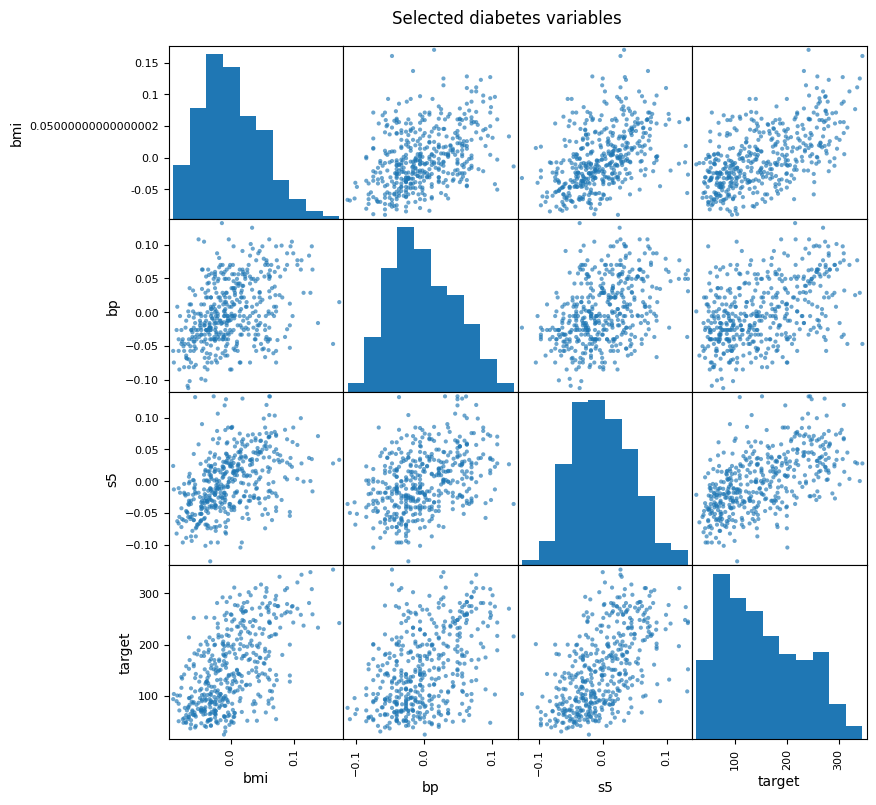

In [4]:
pd.plotting.scatter_matrix(
    data[["bmi", "bp", "s5", "target"]],
    figsize=(9, 9), diagonal="hist", alpha=0.65
)
plt.suptitle("Selected diabetes variables", y=0.92)
plt.show()

# 2. Simple linear regression

We first predict the continuous target using one feature, body mass index (`bmi`). Linear regression estimates an intercept (bias) and a coefficient (weight):

$$\hat{y} = b + w_1x_1.$$

In [5]:
X_simple = data[["bmi"]]
y = data["target"]

# Keep a test set separate so that evaluation reflects unseen observations
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.25, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_s = simple_model.predict(X_test_s)

print(f"Intercept (bias): {simple_model.intercept_:.3f}")
print(f"BMI coefficient (weight): {simple_model.coef_[0]:.3f}")

Intercept (bias): 152.077
BMI coefficient (weight): 975.277


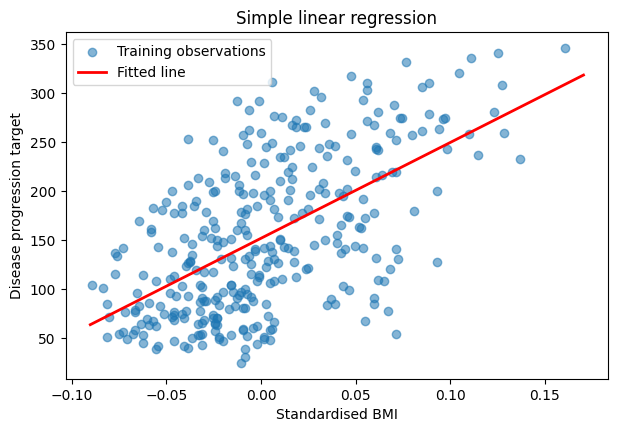

In [6]:
# Plot observations and fitted line
x_grid = pd.DataFrame({"bmi": np.linspace(X_simple.bmi.min(), X_simple.bmi.max(), 200)})
plt.scatter(X_train_s["bmi"], y_train_s, alpha=0.55, label="Training observations")
plt.plot(x_grid["bmi"], simple_model.predict(x_grid), color="red", linewidth=2, label="Fitted line")
plt.xlabel("Standardised BMI")
plt.ylabel("Disease progression target")
plt.title("Simple linear regression")
plt.legend()
plt.show()

## Evaluation: $R^2$, MAE, MSE and RMSE

- $R^2$ is the proportion of variation in the response explained by the model on the evaluated data.
- MAE is the mean absolute distance between predictions and observations.
- MSE is the mean squared distance.
- RMSE is the square root of MSE and is expressed in the response's original units.

In [7]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return pd.Series({
        "R-squared": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse)
    })

regression_metrics(y_test_s, y_pred_s)

,0
R-squared,0.317
MAE,49.805
MSE,3775.617
RMSE,61.446


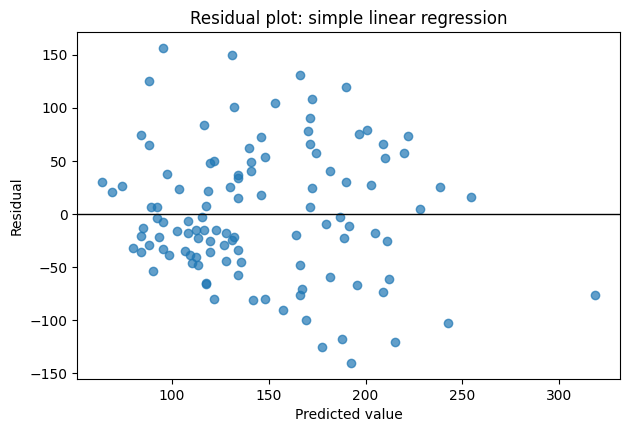

In [8]:
# Residuals are observed minus predicted values
residuals = y_test_s - y_pred_s
plt.axhline(0, color="black", linewidth=1)
plt.scatter(y_pred_s, residuals, alpha=0.7)
plt.xlabel("Predicted value")
plt.ylabel("Residual")
plt.title("Residual plot: simple linear regression")
plt.show()

### Activity 1
1. Replace `bmi` with `bp` or `s5`.
2. Refit the model and calculate the four metrics.
3. Which individual feature gives the best test-set predictions?

# 3. Multiple linear regression

A model with several features gives each feature its own coefficient:

$$\hat{y}=b+w_1x_1+w_2x_2+\cdots+w_px_p.$$

In [10]:
X = data.drop(columns="target")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)
y_pred_multiple = multiple_model.predict(X_test)

comparison = pd.DataFrame({
    "Simple linear regression": regression_metrics(y_test_s, y_pred_s),
    "Multiple linear regression": regression_metrics(y_test, y_pred_multiple)
})
comparison

,Simple linear regression,Multiple linear regression
R-squared,0.317,0.485
MAE,49.805,41.549
MSE,3775.617,2848.311
RMSE,61.446,53.370


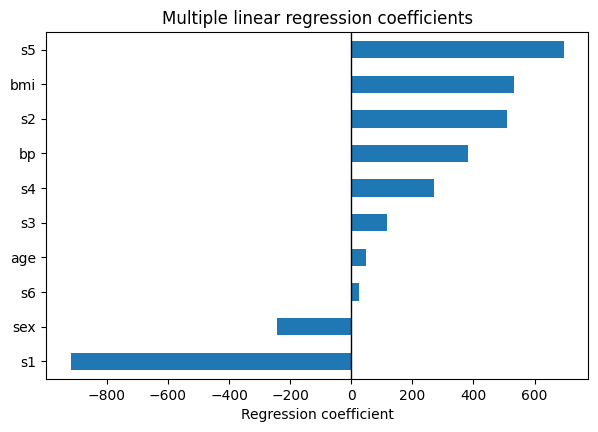

In [11]:
coefficients = pd.Series(multiple_model.coef_, index=X.columns).sort_values()
coefficients.plot(kind="barh")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Regression coefficient")
plt.title("Multiple linear regression coefficients")
plt.show()

**Interpretation caution:** coefficient size is affected by feature scaling and correlation between predictors. Association within this fitted model is not evidence of causation.

# 4. Loss functions and outliers

Loss measures how far predictions are from observed values. L1 loss uses absolute differences, while L2 loss uses squared differences. Squaring gives unusually large errors greater influence.

In [12]:
actual = np.array([24.0, 18.0, 30.0])
predicted = np.array([21.5, 20.0, 28.0])
errors = actual - predicted

pd.DataFrame({
    "actual": actual,
    "predicted": predicted,
    "error": errors,
    "absolute_error_L1": np.abs(errors),
    "squared_error_L2": errors**2
})

,actual,predicted,error,absolute_error_L1,squared_error_L2
0,24.0,21.5,2.5,2.5,6.25
1,18.0,20.0,-2.0,2.0,4.00
2,30.0,28.0,2.0,2.0,4.00


In [13]:
# The worked example from the presentation
actual_value = 24
predicted_value = 21.5
print("L1 loss:", abs(actual_value - predicted_value))
print("L2 loss:", (actual_value - predicted_value)**2)

L1 loss: 2.5
L2 loss: 6.25


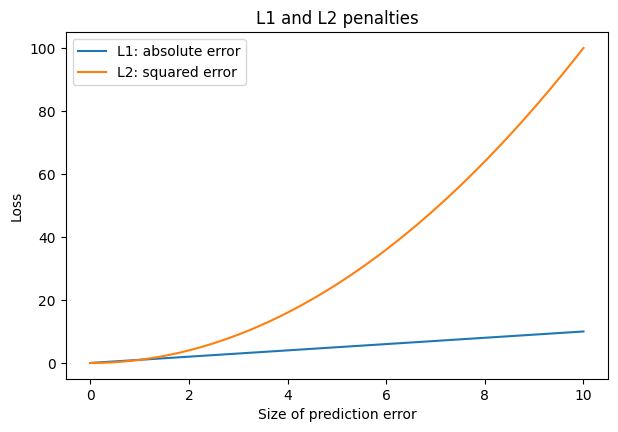

In [14]:
# Compare the effect of one increasingly extreme error
error_size = np.linspace(0, 10, 200)
plt.plot(error_size, error_size, label="L1: absolute error")
plt.plot(error_size, error_size**2, label="L2: squared error")
plt.xlabel("Size of prediction error")
plt.ylabel("Loss")
plt.title("L1 and L2 penalties")
plt.legend()
plt.show()

## MAE versus MSE in the presence of an outlier
The following simulated example adds one extreme response. Ordinary least squares minimises squared error, while median-based fitting illustrates an absolute-error-resistant alternative.

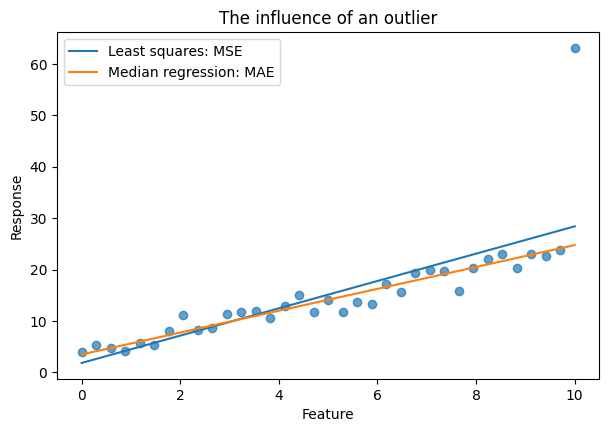

In [15]:
from sklearn.linear_model import QuantileRegressor

rng = np.random.default_rng(7)
x_out = np.linspace(0, 10, 35)
y_out = 4 + 2.2*x_out + rng.normal(0, 2, len(x_out))
y_out[-1] += 35  # deliberately add an outlier
X_out = x_out.reshape(-1, 1)

mse_model = LinearRegression().fit(X_out, y_out)
mae_model = QuantileRegressor(quantile=0.5, alpha=0, solver="highs").fit(X_out, y_out)

grid = np.linspace(0, 10, 200).reshape(-1, 1)
plt.scatter(x_out, y_out, alpha=0.7)
plt.plot(grid, mse_model.predict(grid), label="Least squares: MSE")
plt.plot(grid, mae_model.predict(grid), label="Median regression: MAE")
plt.xlabel("Feature")
plt.ylabel("Response")
plt.title("The influence of an outlier")
plt.legend()
plt.show()

# 5. Gradient descent and convergence

Gradient descent repeatedly adjusts model parameters in the direction that reduces loss. Here we implement it directly for a simple straight-line model so that the loss curve is visible.

In [16]:
# Standardise one feature and the response for stable gradient descent
x_gd = X_train_s["bmi"].to_numpy()
y_gd = y_train_s.to_numpy()
x_gd = (x_gd - x_gd.mean()) / x_gd.std()
y_gd = (y_gd - y_gd.mean()) / y_gd.std()

w, b = 0.0, 0.0
learning_rate = 0.05
iterations = 300
loss_history = []
n = len(y_gd)

for _ in range(iterations):
    prediction = b + w*x_gd
    error = prediction - y_gd
    loss_history.append(np.mean(error**2))
    dw = (2/n) * np.sum(error*x_gd)
    db = (2/n) * np.sum(error)
    w -= learning_rate*dw
    b -= learning_rate*db

print(f"Final standardised weight: {w:.3f}")
print(f"Final standardised bias: {b:.3f}")

Final standardised weight: 0.591
Final standardised bias: -0.000


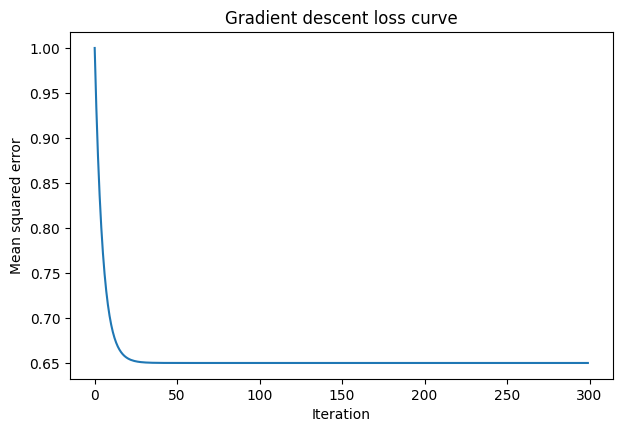

In [17]:
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Mean squared error")
plt.title("Gradient descent loss curve")
plt.show()

### Activity 2
Try learning rates of `0.005`, `0.2` and `1.1`. Which converges slowly, which converges quickly, and which is unstable? Reset `w` and `b` before each run.

# 6. Polynomial regression and overfitting

Polynomial regression first creates powers of the original feature and then fits a linear model. A very flexible polynomial can closely match training observations but generalise poorly.

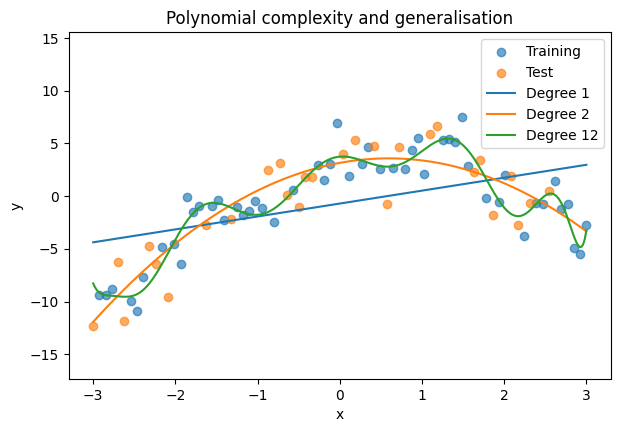

,degree,training_RMSE,test_RMSE
0,1,3.866,4.027
1,2,1.927,2.216
2,12,1.314,2.328


In [18]:
rng = np.random.default_rng(12)
x_poly = np.linspace(-3, 3, 80)
y_poly = 3 + 1.5*x_poly - 1.2*x_poly**2 + rng.normal(0, 2.2, len(x_poly))
X_poly = x_poly.reshape(-1, 1)

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_poly, y_poly, test_size=0.35, random_state=42
)

degrees = [1, 2, 12]
rows = []
grid = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.scatter(Xp_train[:, 0], yp_train, alpha=0.65, label="Training")
plt.scatter(Xp_test[:, 0], yp_test, alpha=0.65, label="Test")
for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(Xp_train, yp_train)
    train_rmse = np.sqrt(mean_squared_error(yp_train, model.predict(Xp_train)))
    test_rmse = np.sqrt(mean_squared_error(yp_test, model.predict(Xp_test)))
    rows.append([degree, train_rmse, test_rmse])
    plt.plot(grid[:, 0], model.predict(grid), label=f"Degree {degree}")

plt.ylim(y_poly.min()-5, y_poly.max()+8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial complexity and generalisation")
plt.legend()
plt.show()

pd.DataFrame(rows, columns=["degree", "training_RMSE", "test_RMSE"])

**Check your understanding:** Which model underfits? Which model is most likely to overfit? Use the gap between training and test RMSE to support your answer.

# 7. Resampling methods

A single train/test split can give a noisy estimate of performance. In $k$-fold cross-validation, the data are divided into $k$ parts. Each part serves as validation data once, and the remaining parts are used for training.

In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Linear regression": LinearRegression(),
    "Decision tree": DecisionTreeRegressor(random_state=42),
    "Random forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

cv_results = []
for name, model in models.items():
    neg_mse = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    rmse = np.sqrt(-neg_mse)
    cv_results.append([name, rmse.mean(), rmse.std()])

pd.DataFrame(cv_results, columns=["model", "mean_CV_RMSE", "SD_CV_RMSE"]).sort_values("mean_CV_RMSE")

,model,mean_CV_RMSE,SD_CV_RMSE
0,Linear regression,54.849,2.641
2,Random forest,57.553,3.437
1,Decision tree,81.198,5.355


# 8. Decision-tree regression

A regression tree recursively divides the predictor space into regions. Each terminal node, or leaf, predicts the mean training response within its region. Deep trees can overfit.

In [20]:
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=12, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
regression_metrics(y_test, y_pred_tree)

,0
R-squared,0.427
MAE,44.526
MSE,3167.396
RMSE,56.280


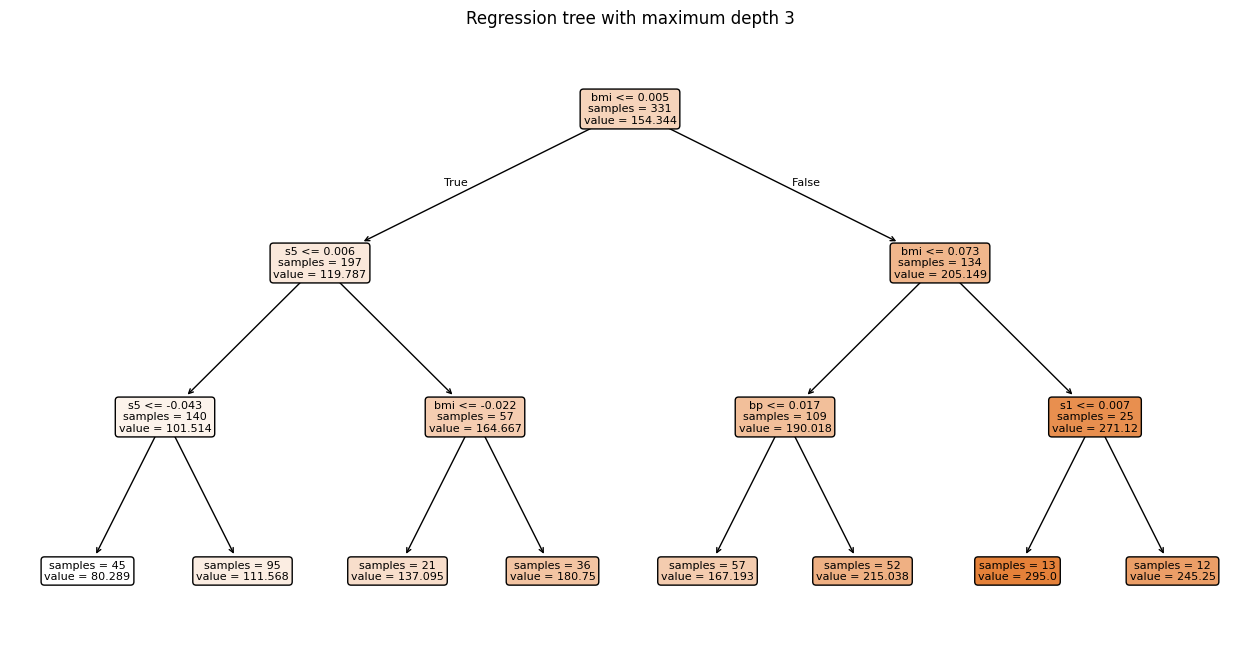

In [21]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree, feature_names=X.columns, filled=True, rounded=True,
    impurity=False, proportion=False, fontsize=8
)
plt.title("Regression tree with maximum depth 3")
plt.show()

## Pruning and model complexity
We use cross-validation to select the cost-complexity pruning parameter `ccp_alpha`. Larger values produce smaller trees.

In [22]:
path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = np.unique(path.ccp_alphas)

# Keep the grid compact for a practical notebook
if len(alphas) > 40:
    alphas = np.quantile(alphas, np.linspace(0, 1, 40))

search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={"ccp_alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv
)
search.fit(X_train, y_train)
pruned_tree = search.best_estimator_

print("Best ccp_alpha:", round(search.best_params_["ccp_alpha"], 5))
print("Leaves before pruning:", DecisionTreeRegressor(random_state=42).fit(X_train, y_train).get_n_leaves())
print("Leaves after pruning:", pruned_tree.get_n_leaves())
regression_metrics(y_test, pruned_tree.predict(X_test))

Best ccp_alpha: 90.99185
Leaves before pruning: 324
Leaves after pruning: 10


,0
R-squared,0.357
MAE,46.497
MSE,3556.409
RMSE,59.636


# 9. Bootstrapping, bagging and random forests

A bootstrap sample is drawn with replacement and has the same size as the original dataset. Bagging fits a model to each bootstrap sample and averages predictions. A random forest adds randomness by considering only a subset of features at each split.

In [23]:
forest = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=3,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
forest.fit(X_train, y_train)
y_pred_forest = forest.predict(X_test)

forest_metrics = regression_metrics(y_test, y_pred_forest)
forest_metrics["OOB R-squared"] = forest.oob_score_
forest_metrics

,0
R-squared,0.494
MAE,42.330
MSE,2796.237
RMSE,52.879
OOB R-squared,0.452


In [24]:
model_comparison = pd.DataFrame({
    "Multiple linear": regression_metrics(y_test, y_pred_multiple),
    "Pruned tree": regression_metrics(y_test, pruned_tree.predict(X_test)),
    "Random forest": regression_metrics(y_test, y_pred_forest)
})
model_comparison

,Multiple linear,Pruned tree,Random forest
R-squared,0.485,0.357,0.494
MAE,41.549,46.497,42.330
MSE,2848.311,3556.409,2796.237
RMSE,53.370,59.636,52.879


# 10. Feature selection and importance

Feature importance can help identify predictors that contribute to a model. Permutation importance measures the increase in prediction error after one feature is randomly shuffled. It is model-agnostic, but correlated predictors can share importance.

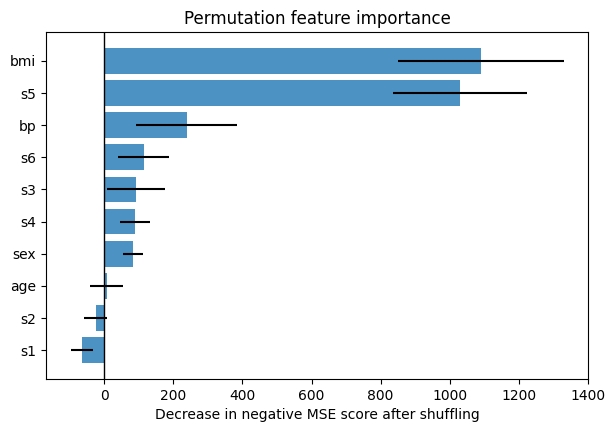

,feature,importance_mean,importance_sd
2,bmi,1089.225,240.520
8,s5,1030.442,193.544
3,bp,238.320,145.481
9,s6,114.154,73.377
6,s3,92.794,84.042
7,s4,89.762,44.080
1,sex,83.964,28.104
0,age,6.935,48.158
5,s2,-24.236,33.897
4,s1,-64.319,32.570


In [25]:
importance = permutation_importance(
    forest, X_test, y_test,
    scoring="neg_mean_squared_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": importance.importances_mean,
    "importance_sd": importance.importances_std
}).sort_values("importance_mean")

plt.barh(importance_df["feature"], importance_df["importance_mean"],
         xerr=importance_df["importance_sd"], alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Decrease in negative MSE score after shuffling")
plt.title("Permutation feature importance")
plt.show()
importance_df.sort_values("importance_mean", ascending=False)

## Optional feature-selection experiment
Select the five most important features using the training data only, then compare a reduced random forest with the full model.

In [26]:
# Compute importance on training data for this teaching demonstration
train_imp = permutation_importance(
    forest, X_train, y_train, scoring="neg_mean_squared_error",
    n_repeats=15, random_state=42, n_jobs=-1
)
top5 = X.columns[np.argsort(train_imp.importances_mean)[-5:]].tolist()

reduced_forest = RandomForestRegressor(
    n_estimators=500, max_features="sqrt", min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
reduced_forest.fit(X_train[top5], y_train)

print("Selected features:", top5)
pd.DataFrame({
    "Full forest": regression_metrics(y_test, forest.predict(X_test)),
    "Reduced forest": regression_metrics(y_test, reduced_forest.predict(X_test[top5]))
})

Selected features: ['s6', 's3', 'bp', 's5', 'bmi']


,Full forest,Reduced forest
R-squared,0.494,0.476
MAE,42.330,43.064
MSE,2796.237,2897.242
RMSE,52.879,53.826


# 11. Prediction bias

Prediction bias can be summarised as the mean prediction minus the mean observed response. A value near zero does not guarantee that every prediction is accurate, so it should be considered alongside error metrics and residual diagnostics.

In [ ]:
def prediction_bias(y_true, y_pred):
    return float(np.mean(y_pred) - np.mean(y_true))

bias_table = pd.Series({
    "Multiple linear regression": prediction_bias(y_test, y_pred_multiple),
    "Pruned decision tree": prediction_bias(y_test, pruned_tree.predict(X_test)),
    "Random forest": prediction_bias(y_test, y_pred_forest)
}, name="prediction_bias")
bias_table

In [ ]:
plt.axhline(0, color="black", linewidth=1)
plt.scatter(y_pred_forest, y_test - y_pred_forest, alpha=0.7)
plt.xlabel("Random-forest prediction")
plt.ylabel("Residual")
plt.title("Check for systematic prediction error")
plt.show()

# 12. Final thoughts

- Linear regression is often effective and interpretable when relationships are approximately linear.
- Polynomial regression can represent curved relationships, but excessive flexibility can overfit.
- Decision trees are easy to explain and can model nonlinearities and interactions, but a single deep tree may be unstable.
- Random forests usually improve predictive stability by averaging many trees, at the cost of simpler interpretation.
- Training performance alone is not enough. Use held-out data or cross-validation.
- Model choice should reflect prediction quality, interpretability, computational cost and the consequences of errors.

# Final activity
Using the same train/test split:

1. Compare linear regression, a pruned tree and a random forest using RMSE, MAE and $R^2$.
2. Explain why the model with the lowest training error need not have the lowest test error.
3. Change `max_features`, `min_samples_leaf` and `n_estimators` in the random forest.
4. Identify the most important features and discuss why importance is not the same as causality.
5. Write a short recommendation choosing a model for either prediction or explanation.